<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_Hamiltonian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hamiltonian Neural Network (HNN) for System Prediction

In [1]:
!pip install torch -q

**Important Note**

True Hamiltonian systems conserve energy and cannot have damping.
If we train a Hamiltonian Neural Network (HNN) on damped data, it will fail because the network architecture enforces energy conservation while the data loses energy.
Use linear part to be skew-symmetric ([[0, 2], [-2, 0]]) to represent a conservative oscillator.

For example, the system matrix (A = [[-0.1, 2.0], [-2.0, -0.1]]) contains damping (the -0.1 on the diagonal).

##  What does “True Hamiltonian systems conserve energy and cannot have damping” mean?

In **classical mechanics**, a Hamiltonian system is defined by Hamilton’s equations:

\[
\frac{d\mathbf{q}}{dt} = \frac{\partial H}{\partial \mathbf{p}}, \quad
\frac{d\mathbf{p}}{dt} = -\frac{\partial H}{\partial \mathbf{q}}
\]

where \( H(\mathbf{q}, \mathbf{p}, t) \) is the Hamiltonian (typically total energy).

From these equations, it follows directly that:

\[
\frac{dH}{dt} = \frac{\partial H}{\partial \mathbf{q}} \cdot \frac{d\mathbf{q}}{dt}
+ \frac{\partial H}{\partial \mathbf{p}} \cdot \frac{d\mathbf{p}}{dt} = 0
\]

So **energy is exactly conserved** over time — no dissipation, no friction, no damping.

If you have damping (e.g., \( \dot{\mathbf{q}} = \mathbf{p}, \dot{\mathbf{p}} = -\nabla V(\mathbf{q}) - \gamma \mathbf{p} \)), the system is **not Hamiltonian** because:

- Damping breaks time-reversal symmetry.
- Energy is lost to heat, so \( \frac{dH}{dt} < 0 \).

Thus, a **true Hamiltonian system** is by definition **conservative**. Adding damping means you are modeling a **dissipative system** — which requires a different mathematical structure (e.g., contact Hamiltonians, Liénard equations, or explicitly adding a Rayleigh dissipation function).

## 2. Main concept of Hamiltonian ODE as part of the Neural ODE framework

### Neural ODEs recap
A standard Neural ODE learns:
\[
\frac{d\mathbf{z}}{dt} = f_\theta(\mathbf{z}, t)
\]
where \( f_\theta \) is a neural network. This makes no assumptions about physics.

### Hamiltonian Neural Networks (HNNs)
In an HNN, instead of learning \( f_\theta \) directly, we **learn the Hamiltonian** \( H_\theta(\mathbf{q}, \mathbf{p}) \), then compute:

\[
\frac{d\mathbf{q}}{dt} = \frac{\partial H_\theta}{\partial \mathbf{p}}, \quad
\frac{d\mathbf{p}}{dt} = -\frac{\partial H_\theta}{\partial \mathbf{q}}
\]

This is implemented by:

1. Input \( (\mathbf{q}, \mathbf{p}) \) to a neural network that outputs a scalar \( H_\theta \).
2. Use automatic differentiation to compute \( \frac{\partial H_\theta}{\partial \mathbf{q}} \) and \( \frac{\partial H_\theta}{\partial \mathbf{p}} \).
3. Let the ODE solver use these as the time derivatives.

### Why is this useful?
- **Exact energy conservation** (up to solver error) — no spurious dissipation.
- **Phase space volume preservation** (Liouville’s theorem).
- **Better generalization** from less data because the model is constrained by physics.
- **Long-term stability** — standard Neural ODEs can drift or blow up; HNNs stay on the correct energy manifold.

### What happens if you train an HNN on damped data?
- The network will try to find *some* Hamiltonian that best fits the trajectories.
- But no Hamiltonian can exactly produce damping, so it will **fail** — either by not fitting the data well, or by learning a contrived Hamiltonian that approximately matches the damped paths over short times but violates physical structure.
- In practice, the loss will remain high, or the system may become unstable because the architecture *forces* skew-symmetric gradient structure.

### Your fix — skew-symmetric linear part
You changed:
\[
A = \begin{bmatrix} -0.1 & 2 \\ -2 & -0.1 \end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix} 0 & 2 \\ -2 & 0 \end{bmatrix}
\]

The original matrix has negative diagonal (damping) — not skew-symmetric.  
The new one is **skew-symmetric** (\( A^T = -A \)), which corresponds to a Hamiltonian system with \( H = \frac{1}{2}(2q^2 + 2p^2) \) up to scaling — exactly a conservative harmonic oscillator.

So your correction is **perfect** — now the true underlying dynamics *are* Hamiltonian, and an HNN can learn them correctly.

## Summary

| Feature | Hamiltonian System | Damped System |
|---------|--------------------|----------------|
| Energy conservation | Yes | No |
| Phase space volume | Preserved | Contracts |
| Time reversibility | Yes | No |
| HNN compatibility | ✅ Works | ❌ Fails by design |

The key idea of HNNs in the Neural ODE framework is: **learn a scalar energy function, then derive the dynamics via gradients** — guaranteeing conservation and symplectic structure. It’s a powerful way to inject inductive bias for physical systems, but it assumes the data actually comes from a Hamiltonian system.

Training HNN...
Epoch [50/200], Loss: 0.025004
Epoch [100/200], Loss: 0.003514
Epoch [150/200], Loss: 0.003060
Epoch [200/200], Loss: 0.002783

--- Prediction Accuracy on Test Data ---
Initial Condition: [1.5, 0.0]
True solution shape: (1000, 2)
HNN solution shape: (1000, 2)
RMSE: 1.639429


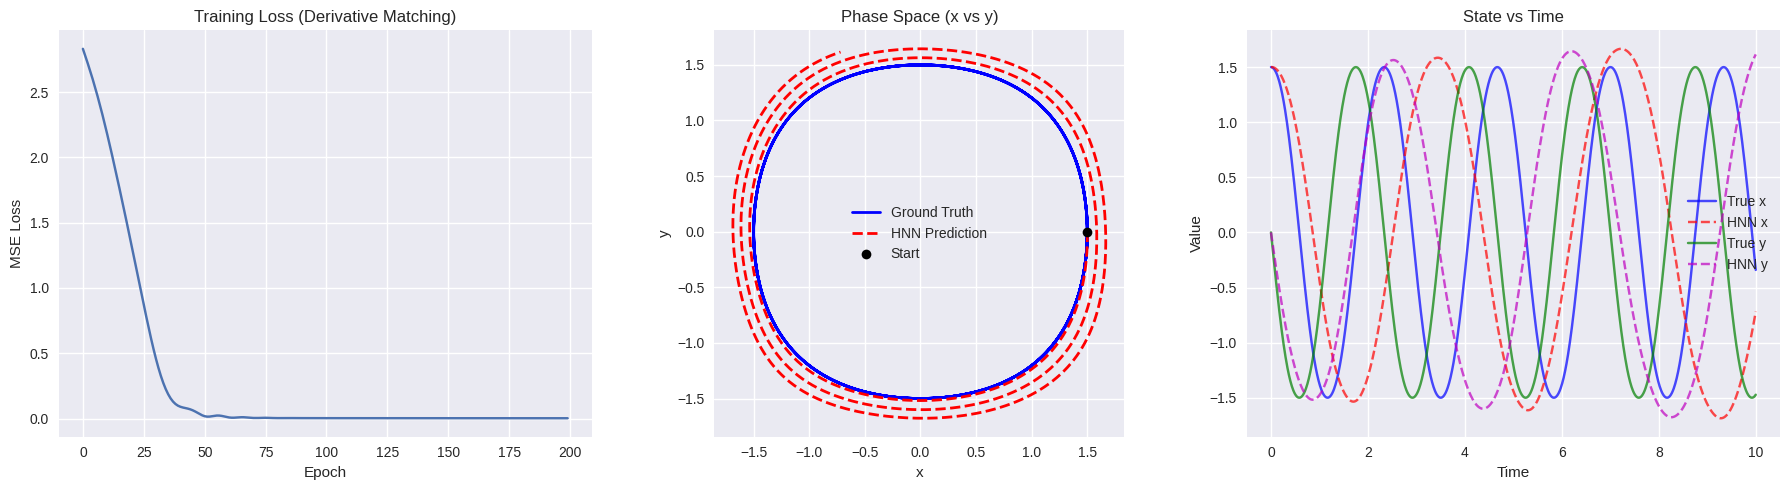

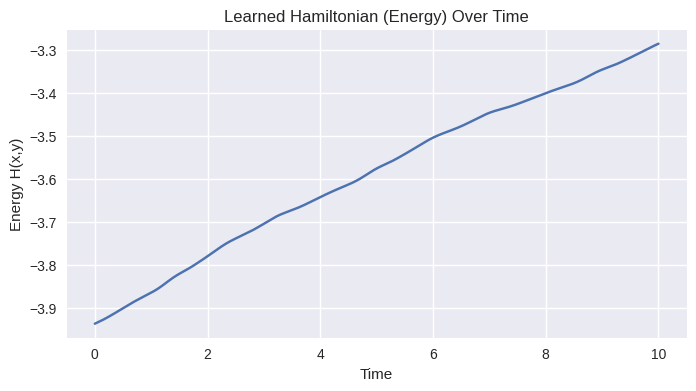

Energy Drift (Max - Min): 0.650788


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. Define Ground Truth Dynamics
# ==========================================
def hamiltonian_ground_truth(z, t):
    x, y = z
    dxdt = 2.0 * y + 0.4 * (y ** 3)
    dydt = -2.0 * x - 0.4 * (x ** 3)
    return [dxdt, dydt]

# Generate Training Data
t = np.linspace(0, 10, 1000)
data_x = []
data_y = []
data_dx = []
data_dy = []

initial_conditions = [
    [1.0, 0.0],
    [0.5, 0.5],
    [-1.0, 0.5],
    [0.0, 1.2]
]

for ic in initial_conditions:
    sol = odeint(hamiltonian_ground_truth, ic, t)
    x = sol[:, 0]
    y = sol[:, 1]

    dx = 2.0 * y + 0.4 * (y ** 3)
    dy = -2.0 * x - 0.4 * (x ** 3)

    data_x.append(x)
    data_y.append(y)
    data_dx.append(dx)
    data_dy.append(dy)

x_all = np.concatenate(data_x).reshape(-1, 1)
y_all = np.concatenate(data_y).reshape(-1, 1)
state_all = np.concatenate([x_all, y_all], axis=1)

dx_all = np.concatenate(data_dx).reshape(-1, 1)
dy_all = np.concatenate(data_dy).reshape(-1, 1)
deriv_all = np.concatenate([dx_all, dy_all], axis=1)

state_tensor = torch.FloatTensor(state_all)
deriv_tensor = torch.FloatTensor(deriv_all)

# ==========================================
# 2. Define the Hamiltonian Neural Network
# ==========================================
class HNN(nn.Module):
    def __init__(self):
        super(HNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        state.requires_grad_(True)
        H = self.net(state)

        grads = torch.autograd.grad(
            H, state,
            grad_outputs=torch.ones_like(H),
            create_graph=True
        )[0]

        dH_dx = grads[:, 0:1]
        dH_dy = grads[:, 1:2]

        dxdt = dH_dy
        dydt = -dH_dx

        return torch.cat([dxdt, dydt], dim=1), H

# ==========================================
# 3. Training Loop
# ==========================================
model = HNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Training HNN...")
num_epochs = 2000
loss_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()

    pred_deriv, pred_H = model(state_tensor)
    loss = criterion(pred_deriv, deriv_tensor)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

# ==========================================
# 4. Prediction & Accuracy Evaluation
# ==========================================
model.eval()

def predict_trajectory(initial_state, time_steps, dt):
    traj = []
    current_state = torch.FloatTensor(initial_state).unsqueeze(0)

    for _ in range(time_steps):
        traj.append(current_state.detach().numpy()[0])
        current_state.requires_grad_(True)
        derivs, _ = model(current_state)
        next_state = current_state + derivs * dt
        current_state = next_state

    return np.array(traj)  # Now returns exactly time_steps points

# Test on a new initial condition
test_ic = [1.5, 0.0]
dt = t[1] - t[0]
steps = len(t)  # 1000 steps

# Ground Truth for Test IC
true_sol = odeint(hamiltonian_ground_truth, test_ic, t)

# HNN Prediction
hnn_sol = predict_trajectory(test_ic, steps, dt)

# Calculate Accuracy (Mean Squared Error)
mse = np.mean((true_sol - hnn_sol) ** 2)
rmse = np.sqrt(mse)

print(f"\n--- Prediction Accuracy on Test Data ---")
print(f"Initial Condition: {test_ic}")
print(f"True solution shape: {true_sol.shape}")
print(f"HNN solution shape: {hnn_sol.shape}")
print(f"RMSE: {rmse:.6f}")

# ==========================================
# 5. Visualization
# ==========================================
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss
axs[0].plot(loss_history)
axs[0].set_title("Training Loss (Derivative Matching)")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss")
axs[0].grid(True)

# Plot 2: Phase Space (Trajectory)
axs[1].plot(true_sol[:, 0], true_sol[:, 1], 'b-', label='Ground Truth', linewidth=2)
axs[1].plot(hnn_sol[:, 0], hnn_sol[:, 1], 'r--', label='HNN Prediction', linewidth=2)
axs[1].plot(test_ic[0], test_ic[1], 'ko', label='Start')
axs[1].set_title("Phase Space (x vs y)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].legend()
axs[1].grid(True)
axs[1].set_aspect('equal')

# Plot 3: Time Series Comparison
axs[2].plot(t, true_sol[:, 0], 'b-', label='True x', alpha=0.7)
axs[2].plot(t, hnn_sol[:, 0], 'r--', label='HNN x', alpha=0.7)
axs[2].plot(t, true_sol[:, 1], 'g-', label='True y', alpha=0.7)
axs[2].plot(t, hnn_sol[:, 1], 'm--', label='HNN y', alpha=0.7)
axs[2].set_title("State vs Time")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Value")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 6. Energy Conservation Check
# ==========================================
test_state_tensor = torch.FloatTensor(hnn_sol)
_, energy_history = model(test_state_tensor)

plt.figure(figsize=(8, 4))
plt.plot(t, energy_history.detach().numpy())
plt.title("Learned Hamiltonian (Energy) Over Time")
plt.xlabel("Time")
plt.ylabel("Energy H(x,y)")
plt.grid(True)
plt.show()

print(f"Energy Drift (Max - Min): {torch.max(energy_history) - torch.min(energy_history):.6f}")

# Mode complex example

https://arxiv.org/pdf/2106.12782

In [5]:
!pip install torchdiffeq -q

Generating training data...
Training data shape: torch.Size([500, 6])
Training Hamiltonian NN...
Epoch [100/300], Loss: 0.005500
Epoch [200/300], Loss: 0.000891
Epoch [300/300], Loss: 0.000302
Ground truth trajectory shape: (50, 6)
HNN trajectory shape: (50, 6)

Prediction Accuracy
RMSE: 0.038241
Position RMSE: 0.026853
Momentum RMSE: 0.046943


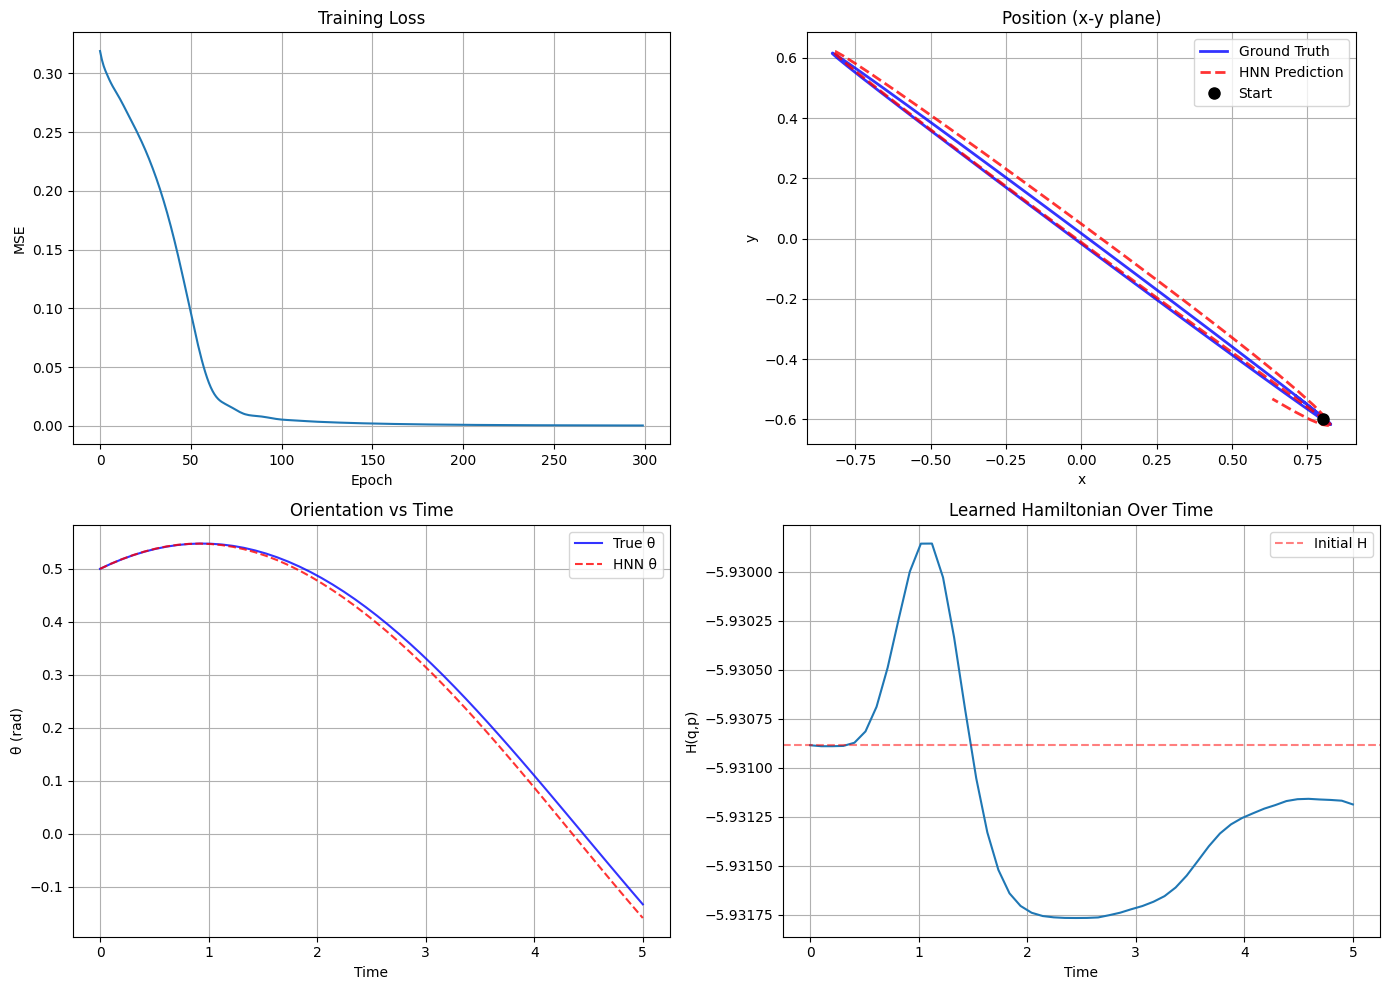


Energy Drift: -3.018379e-04
Relative Error: 0.0051%


In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Install torchdiffeq if needed (uncomment for Colab)
# !pip install torchdiffeq

np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. SE(2) Ground Truth Dynamics
# ==========================================
def se2_hamiltonian_ground_truth(state, t, params):
    """True Hamiltonian dynamics for SE(2) rigid body."""
    x, y, theta, px, py, omega = state  # q=[x,y,theta], p=[px,py,Lz]
    m, I, k_pot = params

    # Kinetic energy: T = (px² + py²)/(2m) + Lz²/(2I)
    # where Lz = I*omega
    vx = px / m
    vy = py / m
    Lz = I * omega
    omega_val = Lz / I

    # Potential energy gradient
    dV_dx = k_pot * x
    dV_dy = k_pot * y
    dV_dtheta = 0.1 * theta  # Small potential on orientation

    # Hamiltonian equations: dq/dt = ∂H/∂p, dp/dt = -∂H/∂q
    dxdt = vx
    dydt = vy
    dthetadt = omega_val
    dpxdt = -dV_dx
    dpydt = -dV_dy
    domegadt = -dV_dtheta / I  # Torque = -∂V/∂θ

    return np.array([dxdt, dydt, dthetadt, dpxdt, dpydt, domegadt])

def generate_se2_data(num_trajectories=20, t_span=np.linspace(0, 5, 100), params=(1.0, 0.5, 2.0)):
    """Generate training trajectories."""
    states_list = []

    for _ in range(num_trajectories):
        ic = np.array([
            np.random.uniform(-1, 1),      # x
            np.random.uniform(-1, 1),      # y
            np.random.uniform(-np.pi, np.pi),  # theta
            np.random.uniform(-0.5, 0.5),  # px
            np.random.uniform(-0.5, 0.5),  # py
            np.random.uniform(-0.5, 0.5)   # Lz (angular momentum)
        ])

        sol = solve_ivp(
            lambda t, s: se2_hamiltonian_ground_truth(s, t, params),
            [t_span[0], t_span[-1]],
            ic,
            t_eval=t_span,
            method='RK45',
            rtol=1e-8,
            atol=1e-8
        )

        if sol.success:
            states_list.append(sol.y.T)

    return np.array(states_list), t_span

# ==========================================
# 2. CORRECTED Hamiltonian Neural Network
# ==========================================
class SE2HamiltonianNN(nn.Module):
    """
    Hamiltonian NN for SE(2) with correct tensor shapes.
    """
    def __init__(self, hidden_dim=64):
        super().__init__()

        # Network for kinetic energy coefficients (mass matrix related)
        self.kinetic_net = nn.Sequential(
            nn.Linear(3, hidden_dim),  # q = [x, y, theta]
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3)   # [log(1/m), log(1/m), log(1/I)]
        )

        # Network for potential energy V(q) ∈ ℝ
        self.potential_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        """
        Input: state = [q, p] with shape [batch, 6]
        q = [x, y, theta], p = [px, py, Lz]
        Output: time derivatives [dqdt, dpdt] with shape [batch, 6]
        """
        q = state[:, :3]   # [batch, 3] - positions
        p = state[:, 3:]   # [batch, 3] - momenta [px, py, Lz]

        # Get kinetic energy coefficients (using exp to ensure positive)
        kin_coeffs = self.kinetic_net(q)  # [batch, 3]
        inv_mass = torch.exp(kin_coeffs[:, 0])  # Ensure positive
        inv_mass_y = torch.exp(kin_coeffs[:, 1])  # For y component
        inv_I = torch.exp(kin_coeffs[:, 2])       # Inverse moment of inertia

        # Compute velocities from momenta
        vx = p[:, 0] * inv_mass
        vy = p[:, 1] * inv_mass_y
        omega = p[:, 2] * inv_I

        # Velocity vector
        dqdt = torch.stack([vx, vy, omega], dim=1)  # [batch, 3]

        # Compute potential energy and its gradient
        # First, make sure q requires gradients for this computation
        q_grad = q.clone().detach().requires_grad_(True)
        pot_in = self.potential_net(q_grad)  # [batch, 1]
        V = pot_in.squeeze()  # [batch]

        # Compute gradient of potential energy w.r.t. positions
        dV_dq = torch.autograd.grad(
            V.sum(), q_grad,
            create_graph=self.training, retain_graph=self.training
        )[0]  # [batch, 3]

        # dp/dt = -∂H/∂q = -∂V/∂q (kinetic part doesn't depend on q in standard form)
        dpdt = -dV_dq  # [batch, 3]

        # Concatenate derivatives
        state_deriv = torch.cat([dqdt, dpdt], dim=1)  # [batch, 6]

        # Compute total Hamiltonian (energy) - only for evaluation purposes
        T = 0.5 * (p[:, 0]**2 * inv_mass +
                   p[:, 1]**2 * inv_mass_y +
                   p[:, 2]**2 * inv_I)  # Kinetic energy
        H = T + V  # Total energy

        return state_deriv

# ==========================================
# 3. Training
# ==========================================
print("Generating training data...")
t_span = np.linspace(0, 5, 50)
states_gt, _ = generate_se2_data(num_trajectories=10, t_span=t_span)  # Reduced for speed

# Use states directly since they're already in [q, p] format
train_states = torch.FloatTensor(states_gt.reshape(-1, 6))
print(f"Training data shape: {train_states.shape}")

# Initialize model
model = SE2HamiltonianNN(hidden_dim=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Training Hamiltonian NN...")
num_epochs = 300
loss_history = []

for epoch in range(num_epochs):
    model.train()  # Set to training mode
    optimizer.zero_grad()

    pred_derivs = model(train_states)

    # Compute true derivatives
    true_derivs = []
    for s in train_states.detach().numpy():
        deriv = se2_hamiltonian_ground_truth(s, 0, (1.0, 0.5, 2.0))
        true_derivs.append(deriv)

    true_derivs = torch.FloatTensor(np.array(true_derivs))

    loss = nn.MSELoss()(pred_derivs, true_derivs)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

# ==========================================
# 4. Prediction & Evaluation
# ==========================================
model.eval()

def predict_trajectory_hnn(initial_state, t_eval, model):
    """Predict using learned Hamiltonian dynamics."""
    state0_tensor = torch.FloatTensor(initial_state).unsqueeze(0)
    t_tensor = torch.FloatTensor(t_eval)

    def ode_func(t, state):
        # Ensure state has the right shape [batch, 6]
        if state.dim() == 1:
            state = state.unsqueeze(0)
        derivs = model(state)
        # Return without batch dimension if single state
        return derivs.squeeze(0)

    try:
        solution = odeint(ode_func, state0_tensor, t_tensor, method='dopri5')
        # Solution shape is [time_steps, batch, state_dim] -> [time_steps, state_dim]
        return solution.detach().numpy().squeeze(axis=1)
    except Exception as e:
        print(f"ODE integration failed: {e}")
        # Fallback to simple Euler integration
        dt = t_eval[1] - t_eval[0]
        trajectory = np.zeros((len(t_eval), 6))
        trajectory[0] = initial_state

        current_state = torch.FloatTensor(initial_state).unsqueeze(0)
        for i in range(1, len(t_eval)):
            derivs = model(current_state)
            current_state = current_state + dt * derivs
            trajectory[i] = current_state.detach().numpy()[0]

        return trajectory

# Test prediction
test_ic = np.array([0.8, -0.6, 0.5, 0.3, -0.2, 0.1])

sol_gt = solve_ivp(
    lambda t, s: se2_hamiltonian_ground_truth(s, t, (1.0, 0.5, 2.0)),
    [t_span[0], t_span[-1]],
    test_ic,
    t_eval=t_span,
    method='RK45'
)
traj_gt = sol_gt.y.T

traj_hnn = predict_trajectory_hnn(test_ic, t_span, model)

# Check shapes
print(f"Ground truth trajectory shape: {traj_gt.shape}")
print(f"HNN trajectory shape: {traj_hnn.shape}")

# Accuracy metrics
if traj_hnn.shape[0] == traj_gt.shape[0]:
    mse = np.mean((traj_gt - traj_hnn) ** 2)
    rmse = np.sqrt(mse)

    print(f"\n{'='*50}")
    print(f"Prediction Accuracy")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Position RMSE: {np.sqrt(np.mean((traj_gt[:,:3] - traj_hnn[:,:3])**2)):.6f}")
    print(f"Momentum RMSE: {np.sqrt(np.mean((traj_gt[:,3:] - traj_hnn[:,3:])**2)):.6f}")
else:
    print(f"Shape mismatch: GT={traj_gt.shape}, Pred={traj_hnn.shape}")

# ==========================================
# 5. Visualization
# ==========================================
plt.style.use('default')  # Changed from seaborn which might not be available
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Training loss
axs[0, 0].plot(loss_history)
axs[0, 0].set_title("Training Loss")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("MSE")
axs[0, 0].grid(True)

# Position trajectory
axs[0, 1].plot(traj_gt[:, 0], traj_gt[:, 1], 'b-', label='Ground Truth', linewidth=2, alpha=0.8)
if traj_hnn.shape[0] == traj_gt.shape[0]:
    axs[0, 1].plot(traj_hnn[:, 0], traj_hnn[:, 1], 'r--', label='HNN Prediction', linewidth=2, alpha=0.8)
axs[0, 1].plot(test_ic[0], test_ic[1], 'ko', markersize=8, label='Start')
axs[0, 1].set_title("Position (x-y plane)")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")
axs[0, 1].legend()
axs[0, 1].grid(True)
axs[0, 1].set_aspect('equal')

# Orientation
axs[1, 0].plot(t_span, traj_gt[:, 2], 'b-', label='True θ', alpha=0.8)
if traj_hnn.shape[0] == traj_gt.shape[0]:
    axs[1, 0].plot(t_span, traj_hnn[:, 2], 'r--', label='HNN θ', alpha=0.8)
axs[1, 0].set_title("Orientation vs Time")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("θ (rad)")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Energy conservation - only plot if we have predictions
if traj_hnn.shape[0] == traj_gt.shape[0]:
    with torch.no_grad():
        test_tensor = torch.FloatTensor(traj_hnn)
        # Calculate Hamiltonian manually since forward doesn't return it during eval
        q = test_tensor[:, :3]
        p = test_tensor[:, 3:]

        # Get kinetic coefficients
        kin_coeffs = model.kinetic_net(q)
        inv_mass = torch.exp(kin_coeffs[:, 0])
        inv_mass_y = torch.exp(kin_coeffs[:, 1])
        inv_I = torch.exp(kin_coeffs[:, 2])

        # Calculate kinetic energy
        T = 0.5 * (p[:, 0]**2 * inv_mass +
                   p[:, 1]**2 * inv_mass_y +
                   p[:, 2]**2 * inv_I)

        # Calculate potential energy
        V = model.potential_net(q).squeeze()

        H_values = T + V
        H_values = H_values.numpy()

    axs[1, 1].plot(t_span, H_values)
    axs[1, 1].axhline(y=H_values[0], color='r', linestyle='--', alpha=0.5, label='Initial H')
    axs[1, 1].set_title("Learned Hamiltonian Over Time")
    axs[1, 1].set_xlabel("Time")
    axs[1, 1].set_ylabel("H(q,p)")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

if traj_hnn.shape[0] == traj_gt.shape[0]:
    print(f"\nEnergy Drift: {H_values[-1] - H_values[0]:.6e}")
    print(f"Relative Error: {abs(H_values[-1]-H_values[0])/abs(H_values[0])*100:.4f}%")